In [2]:
import pandas as pd

FILE = "../data/raw/AAPL_1h.csv"

df = pd.read_csv(FILE, header=[0,1], index_col=0)

# convert index to datetime
df.index = pd.to_datetime(df.index)

# flatten columns (keep first level only)
df.columns = df.columns.get_level_values(0)

df = df.sort_index()

print(df.shape)
df.head()


(411, 6)


Datetime,Adj Close,Close,High,Low,Open,Volume
2025-11-19 15:30:00+00:00,269.730011,269.730011,272.010010,269.320099,271.850098,2792346
2025-11-19 16:30:00+00:00,270.399994,270.399994,270.654999,269.529999,269.750000,2001030
2025-11-19 17:30:00+00:00,270.029999,270.029999,271.309998,269.619995,270.459991,2049762
2025-11-19 18:30:00+00:00,269.670013,269.670013,271.010010,269.630005,270.010010,1644126
2025-11-19 19:30:00+00:00,270.035004,270.035004,270.734985,269.170013,269.670013,2137859


In [3]:
df["target"] = df["Close"].shift(-1)
df[["Close", "target"]].head()


Datetime,Close,target
2025-11-19 15:30:00+00:00,269.730011,270.399994
2025-11-19 16:30:00+00:00,270.399994,270.029999
2025-11-19 17:30:00+00:00,270.029999,269.670013
2025-11-19 18:30:00+00:00,269.670013,270.035004
2025-11-19 19:30:00+00:00,270.035004,268.570007


In [4]:
import numpy as np

# returns
df["return_1h"] = df["Close"].pct_change()

# lag (memory)
df["close_lag1"] = df["Close"].shift(1)
df["close_lag2"] = df["Close"].shift(2)
df["close_lag3"] = df["Close"].shift(3)

# candle shape
df["hl_range"] = (df["High"] - df["Low"]) / df["Close"]
df["oc_change"] = (df["Close"] - df["Open"]) / df["Open"]

# rolling trend + volatility
df["ma_5"] = df["Close"].rolling(5).mean()
df["std_5"] = df["Close"].rolling(5).std()


In [5]:
df_ml = df.dropna().copy()
df_ml.shape


(406, 15)

In [6]:
features = [
    "Close", "return_1h", "close_lag1", "close_lag2", "close_lag3",
    "hl_range", "oc_change", "ma_5", "std_5"
]

X = df_ml[features]
y = df_ml["target"]

print(X.shape, y.shape)


(406, 9) (406,)


In [7]:
print(X.shape, y.shape)


(406, 9) (406,)


In [8]:
import numpy as np

n = len(df_ml)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val,   y_val   = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test,  y_test  = X.iloc[val_end:], y.iloc[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (284, 9) (284,)
Val:   (61, 9) (61,)
Test:  (61, 9) (61,)


In [9]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

pred_val  = model.predict(X_val)
pred_test = model.predict(X_test)


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("VAL  MAE:", mean_absolute_error(y_val, pred_val))
print("VAL  RMSE:", rmse(y_val, pred_val))

print("TEST MAE:", mean_absolute_error(y_test, pred_test))
print("TEST RMSE:", rmse(y_test, pred_test))


VAL  MAE: 1.2492446335352414
VAL  RMSE: 1.8942349685620286
TEST MAE: 1.2446682935396483
TEST RMSE: 1.761145652747685


In [11]:
naive_test = X_test["Close"].values

print("NAIVE TEST MAE:", mean_absolute_error(y_test, naive_test))
print("NAIVE TEST RMSE:", rmse(y_test, naive_test))


NAIVE TEST MAE: 1.228847816342212
NAIVE TEST RMSE: 1.7403712297528109


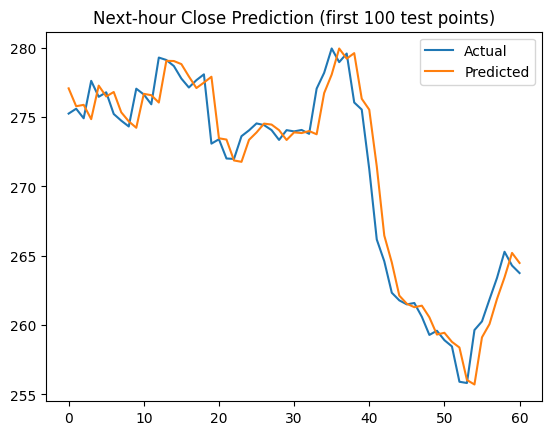

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test.values[:100], label="Actual")
plt.plot(pred_test[:100], label="Predicted")
plt.legend()
plt.title("Next-hour Close Prediction (first 100 test points)")
plt.show()
